#import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Load the dataset

In [3]:
df = pd.read_csv("../data/adult.csv")


#Display first five records

In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


#Understand Dataset Structure

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#Check Dataset Shape

In [6]:
df.shape


(32561, 15)

#Display Column Names

In [7]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

#Check Null Values

In [8]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

#Check Missing Values Represented as '?'

In [9]:
(df == '?').sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

#Replace Missing Value with nan

In [10]:
import numpy as np

df = df.replace("?", np.nan)

#Fill Missing Values in Categorical Columns

In [11]:
for col in ["workclass", "occupation","native.country"]:
    df[col] = df[col].fillna(df[col].mode()[0])

#Verify Missing Values

In [12]:
(df == '?').sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

#Check Total Duplicates

In [13]:
df.duplicated().sum()

np.int64(24)

#Drop Duplicates

In [24]:
df = df.drop_duplicates().reset_index(drop=True)

In [26]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,Target
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329,0.294311
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889,0.455739
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000,1.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [27]:
df.shape

(32537, 17)

#Create Roll Rate Buckets Based on Hours Worked Per Week

In [28]:
bins = [0, 20, 40, 60, 100]

labels = [
    "0-20 Hours",
    "21-40 Hours",
    "41-60 Hours",
    "60+ Hours"
]

df["Roll_Rate_Bucket"] = pd.cut(
    df["hours.per.week"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

#Display Roll Rate Bucket Distribution

In [29]:
df["Roll_Rate_Bucket"].value_counts()

Roll_Rate_Bucket
21-40 Hours    20037
41-60 Hours     8466
0-20 Hours      2924
60+ Hours       1110
Name: count, dtype: int64

#Create Target Variable using Roll Rate Buckets

In [19]:
df["Target"] = df["Roll_Rate_Bucket"].map({
    "0-20 Hours" : 0,
    "21-40 Hours": 0,
    "41-60 Hours" : 1,
    "60+ Hours" : 1
})

#Display Target Distribution

In [31]:
df["Target"].value_counts()

Target
0    22961
1     9576
Name: count, dtype: int64

#Drop Unnecessary Column

In [35]:
df = df.drop(columns=["income", "Roll_Rate_Bucket"])


#Import ScorecardPy Library for WOE and IV

In [36]:
import scorecardpy as sc

d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#Calculate Weight Of Evidence

In [ ]:
bins = sc.woebin(df, y = "Target")

#Apply WOE Transformation

In [38]:
df_woe = sc.woebin_ply(df, bins)
df_woe.head()

[INFO] converting into woe values ...


,Target,native.country_woe,age_woe,occupation_woe,capital.gain_woe,workclass_woe,relationship_woe,education_woe,marital.status_woe,capital.loss_woe,fnlwgt_woe,education.num_woe,sex_woe,hours.per.week_woe,race_woe
0,0,0.037078,-0.672869,0.031983,-0.055983,-0.118812,0.012494,-0.158076,-0.557508,0.0,0.103081,-0.152118,-0.770558,0.0,0.097620
1,0,0.037078,-0.672869,0.638195,-0.055983,-0.118812,0.012494,-0.158076,-0.557508,0.0,0.014638,-0.152118,-0.770558,0.0,0.097620
2,0,0.037078,-0.672869,0.031983,-0.055983,-0.118812,-0.502711,-0.158076,-0.557508,0.0,0.014638,-0.152118,-0.770558,0.0,-0.689042
3,0,0.037078,0.218891,-0.542890,-0.055983,-0.118812,-0.502711,-0.158076,-0.044908,0.0,0.014638,-0.668578,-0.770558,0.0,0.097620
4,0,0.037078,0.218891,0.031983,-0.055983,-0.118812,-1.265639,-0.158076,-0.557508,0.0,-0.043541,-0.152118,-0.770558,0.0,0.097620


#Display Information Values (IV) of Features

In [39]:
iv_df = sc.iv(df, y="Target")
iv_df

,variable,info_value
12,hours.per.week,15.414987
2,occupation,0.363579
5,relationship,0.357416
1,age,0.345023
9,fnlwgt,0.254056
11,sex,0.225625
7,marital.status,0.199265
10,education.num,0.186935
6,education,0.186935
4,workclass,0.157276


#Import library for VIF Calculation

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Select Independent variable

In [41]:
X = df_woe.drop(columns=["Target"])

#Calculate VIF For Each Feature

In [42]:
vif = pd.DataFrame()

vif["feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

d:\anaconda3\envs\ds311\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
0,native.country_woe,1.051583
1,age_woe,1.325836
2,occupation_woe,1.185409
3,capital.gain_woe,1.051794
4,workclass_woe,1.071578
5,relationship_woe,2.221375
6,education_woe,31.151994
7,marital.status_woe,1.896644
8,capital.loss_woe,NaN
9,fnlwgt_woe,1.015950


#Drop Constant Feature

In [46]:
df_woe = df_woe.drop(columns=["capital.loss_woe", "hours.per.week_woe"])

#Drop Highly Correlated Feature

In [48]:
df_woe = df_woe.drop(columns=["education.num_woe"])

#Update Feature Matrix

In [52]:
X = df_woe.drop(columns={"Target"})
y = df_woe["Target"]

#Recalculate VIF

In [53]:
vif = pd.DataFrame()

vif["feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,feature,VIF
0,native.country_woe,1.049596
1,age_woe,1.325764
2,occupation_woe,1.184941
3,capital.gain_woe,1.050769
4,workclass_woe,1.070648
5,relationship_woe,2.220060
6,education_woe,1.139976
7,marital.status_woe,1.896464
8,fnlwgt_woe,1.015883
9,sex_woe,1.363757


Conclusion:
All remaining features have VIF values less than 5, indicating that there is no significant multicollinearity among the independent variables. Therefore, all remaining features are retained for model building.

#Split Data Into Training and Testing Sets

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.25,
    random_state = 42,
    stratify = y
)

#Import Logistic Regression and GridSearchCV

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Create Logistic Regression Model

In [56]:
log_model = LogisticRegression(max_iter=1000)

#Define Hyperparameter Grid

In [57]:
param_grid = {
    "C" : [0.01, 0.1, 1, 10] ,
    "solver" : ["liblinear", "lbfgs"]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [58]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv = 5,
    scoring="f1",
    n_jobs = -1
)

#Train Logistic Regression Model

In [59]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

#Display Best Hyperparameters

In [60]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'C': 10, 'solver': 'liblinear'}
Best F1 Score : 0.40937772629231883


#Predict Target Values on Test Data

In [61]:
y_pred = grid_search.predict(X_test)

#Import Model Evaluation Metrics

In [62]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

#Evaluate Logistic Regression Model

In [63]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.7392747387830363
Precision : 0.6134663341645885
Recall : 0.3082706766917293
F1 : 0.4103419516263553


#Display Confusion Matrix

In [64]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5276  465]
 [1656  738]]


#Display Classification Report

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.92      0.83      5741
           1       0.61      0.31      0.41      2394

    accuracy                           0.74      8135
   macro avg       0.69      0.61      0.62      8135
weighted avg       0.72      0.74      0.71      8135



#Import Decision Tree and GridSearchCV

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

#Create Decision Tree Classifier

In [68]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

#Define Hyperparameters for Decision Tree

In [69]:
param_grid = {
    "criterion" : ["gini", "entropy"],
    "max_depth" : [3, 5, 7, 10],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [70]:
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv = 5,
    scoring="f1",
    n_jobs=-1
)

#Train Decision Tree Model

In [71]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

#Display Best Hyperparameters

In [72]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best F1 Score : 0.48670193252062666


#Predict Target Values on Test Dataset

In [73]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [74]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

#Evaluate Decision Tree Model

In [75]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.7449293177627535
Precision : 0.5983960518198643
Recall : 0.4051796157059315
F1 : 0.48318804483188044


#Display Confusion Matrix

In [76]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5090  651]
 [1424  970]]


#Display Classification Report

In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.89      0.83      5741
           1       0.60      0.41      0.48      2394

    accuracy                           0.74      8135
   macro avg       0.69      0.65      0.66      8135
weighted avg       0.73      0.74      0.73      8135



#Display Feature Importance

In [78]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

               Feature  Importance
5     relationship_woe    0.245290
2       occupation_woe    0.209606
1              age_woe    0.127371
6        education_woe    0.100601
8           fnlwgt_woe    0.076480
4        workclass_woe    0.075722
9              sex_woe    0.054191
10            race_woe    0.040015
7   marital.status_woe    0.032411
3     capital.gain_woe    0.021080


### This tells us which features contributed the most to the Decision Tree.

#Visualize Decision Tree

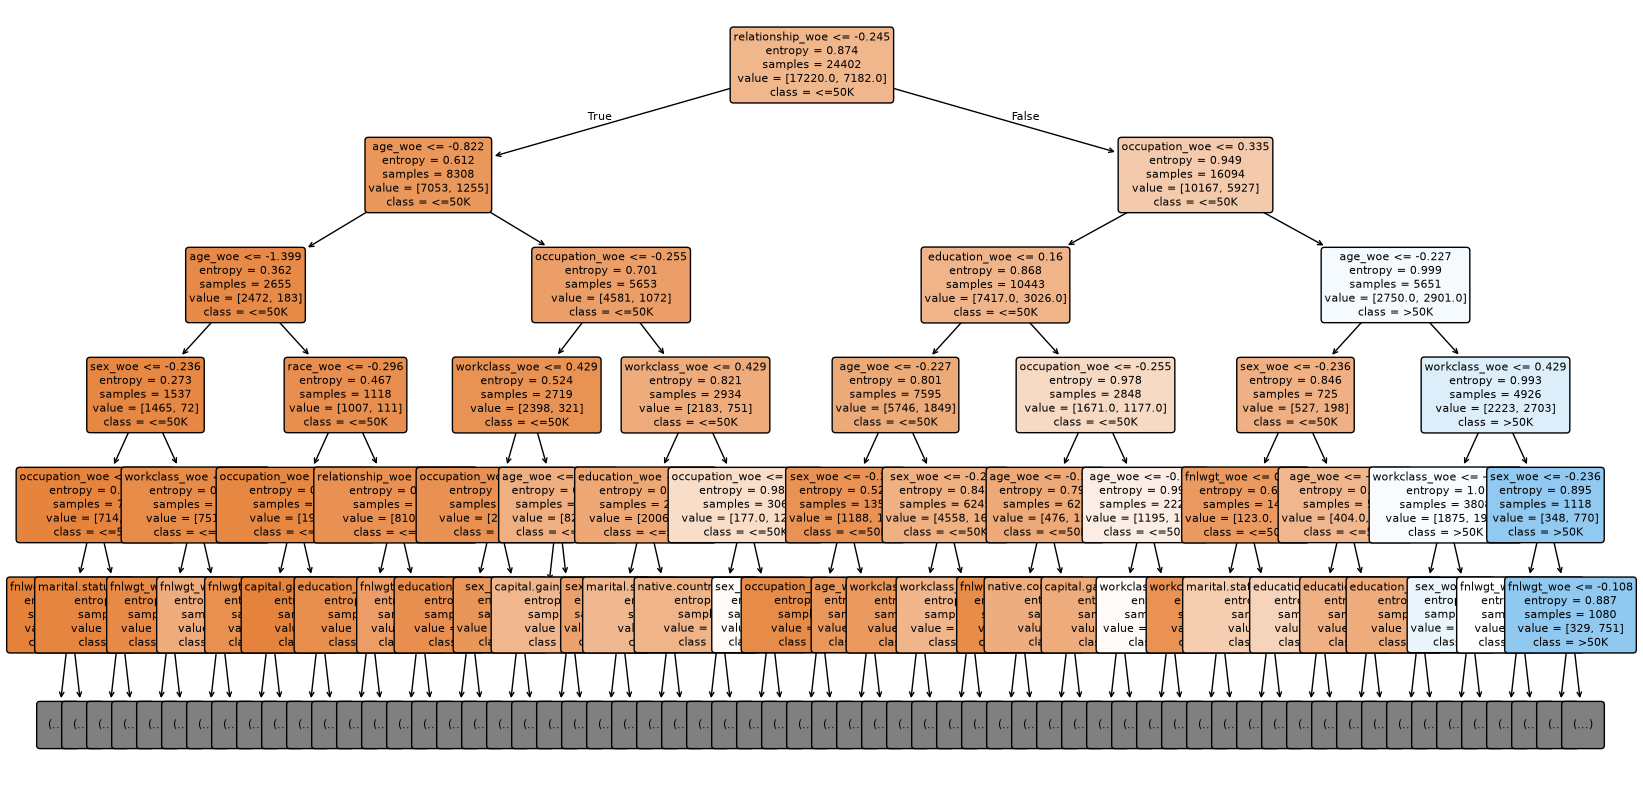

In [80]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    grid_search.best_estimator_,
    feature_names = X.columns,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    max_depth=5,
    fontsize=8
)

plt.show()

# Final Conclusion

## Conclusion:

Both Logistic Regression and Decision Tree models were trained and evaluated on the Adult Income dataset after performing data preprocessing, WOE encoding, IV-based feature selection, VIF analysis, and hyperparameter tuning using GridSearchCV.

Logistic Regression achieved an Accuracy of 73.93% and an F1 Score of 0.4103, while Decision Tree achieved an Accuracy of 74.49% and an F1 Score of 0.4832.

Although Logistic Regression produced slightly higher Precision, the Decision Tree model achieved better Accuracy, Recall, and F1 Score. Since F1 Score provides a balanced evaluation of Precision and Recall, Decision Tree demonstrated better overall classification performance on this dataset.

Therefore, Decision Tree is selected as the final model for this project.